### Aerial Object Classification — Bird vs Drone

This notebook classifies aerial images as **Bird** or **Drone** using two approaches:
a Custom CNN trained from scratch, and Transfer Learning with MobileNetV2.


## 1. Setup

In [2]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR = r"C:\Users\relan\OneDrive\Desktop\Areal_Project\classification_dataset"  # bird/ and drone/ subfolders under train/valid/test


## 2. Understand the Dataset

Inspect folder structure, class balance, and sample images before doing anything else.


In [3]:
for split in ["train", "valid", "test"]:
    for cls in ["bird", "drone"]:
        path = os.path.join(DATA_DIR, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"{split:6s} {cls:6s}: {n} images")


train  bird  : 1416 images
train  drone : 1248 images
valid  bird  : 217 images
valid  drone : 225 images
test   bird  : 121 images
test   drone : 94 images


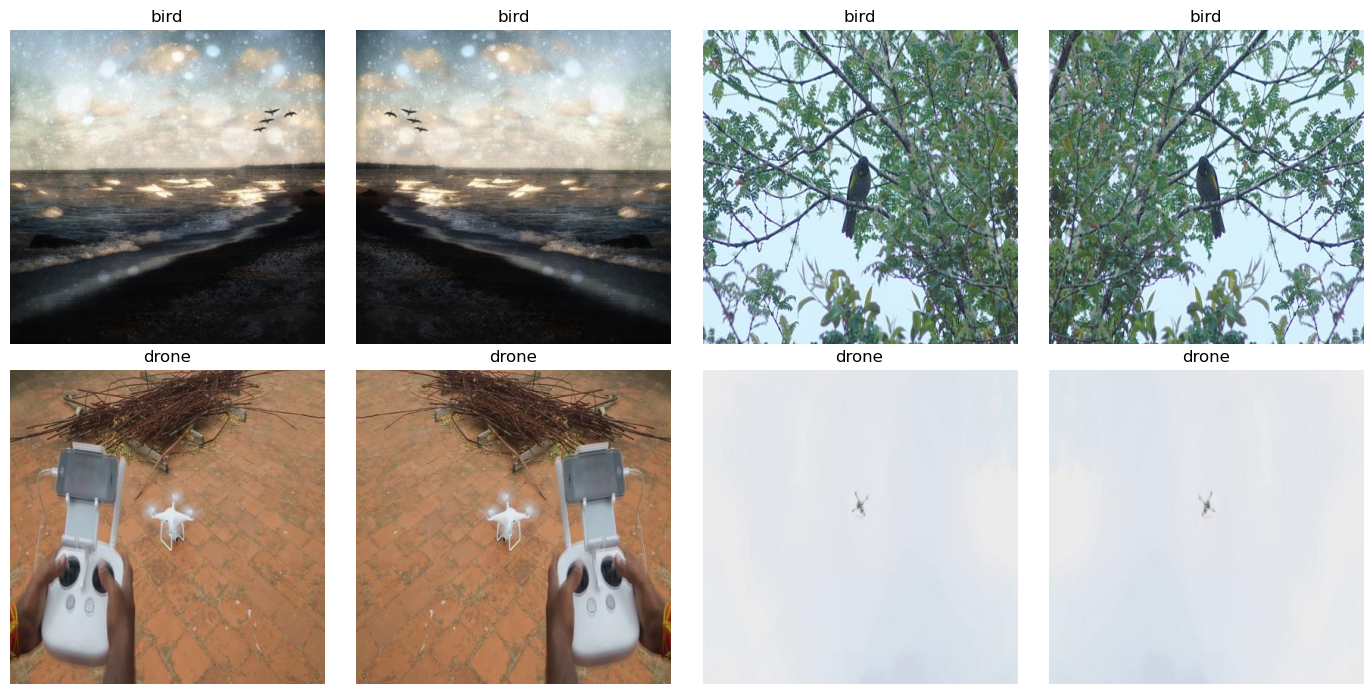

In [4]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(["bird", "drone"]):
    folder = os.path.join(DATA_DIR, "train", cls)
    files = os.listdir(folder)[:4]
    for col, fname in enumerate(files):
        img = plt.imread(os.path.join(folder, fname))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()


**Important finding (see Section 7 for full detail):** every image in this dataset
is exactly 416×416 and named with a Roboflow-style `.rf.<hash>` suffix. This dataset was
originally exported for object detection and converted to classification by cropping
tightly to the annotated object — so the bird/drone fills most of the frame in nearly
every image. Real-world photos where the subject is small and far away look nothing
like this. Section 4's data augmentation deliberately compensates for this.


## 3. Preprocessing

In [5]:
IMG_SIZE_CNN = (128, 128)      # smaller input for the custom CNN (faster to train from scratch)
IMG_SIZE_TRANSFER = (224, 224) # required input size for MobileNetV2


## 4. Data Augmentation (including synthetic distance simulation)

Standard augmentations (rotation, shift, shear, zoom, brightness, flip) are combined with
a **custom synthetic distance augmentation**: for ~50% of training images, the object is
shrunk down and pasted onto a blurred version of itself, simulating what a genuinely
distant version of the same photo would look like. This directly targets the dataset
bias described above, instead of only ever showing the model close-up, object-filling
crops.


In [6]:
def simulate_distance(img_array, prob=0.5, scale_range=(0.12, 0.5)):
    """Shrinks the (already object-filling) image and pastes it onto a blurred
    version of itself, simulating a small/distant subject."""
    if random.random() > prob:
        return img_array
    h, w = img_array.shape[:2]
    scale = random.uniform(*scale_range)
    small_size = max(10, int(min(h, w) * scale))
    obj_small = cv2.resize(img_array, (small_size, small_size), interpolation=cv2.INTER_AREA)
    sigma = random.uniform(8, 20)
    bg = cv2.GaussianBlur(img_array, (0, 0), sigmaX=sigma)
    bg = np.clip(bg * random.uniform(0.85, 1.05), 0, 255)
    x0 = random.randint(0, max(w - small_size, 0))
    y0 = random.randint(0, max(h - small_size, 0))
    canvas = bg.copy()
    canvas[y0:y0 + small_size, x0:x0 + small_size] = obj_small
    return canvas.astype(np.float32)


def make_preprocess_fn(preprocess_base_fn, training):
    def _fn(img_array):
        if training:
            img_array = simulate_distance(img_array)
        return preprocess_base_fn(img_array)
    return _fn


def rescale_0_1(img_array):
    return img_array / 255.0


In [7]:
# Generators for the Custom CNN (128x128, rescale to [0,1])
train_datagen_cnn = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, brightness_range=(0.8, 1.2), horizontal_flip=True,
    preprocessing_function=make_preprocess_fn(rescale_0_1, training=True),
)
val_datagen_cnn = ImageDataGenerator(preprocessing_function=make_preprocess_fn(rescale_0_1, training=False))

train_gen_cnn = train_datagen_cnn.flow_from_directory(
    os.path.join(DATA_DIR, "train"), target_size=IMG_SIZE_CNN, batch_size=32,
    class_mode="binary", classes=["bird", "drone"], seed=SEED)
val_gen_cnn = val_datagen_cnn.flow_from_directory(
    os.path.join(DATA_DIR, "valid"), target_size=IMG_SIZE_CNN, batch_size=32,
    class_mode="binary", classes=["bird", "drone"], shuffle=False)


Found 2663 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


In [8]:
# Generators for Transfer Learning (224x224, MobileNetV2 preprocessing)
train_datagen_tl = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.1, brightness_range=(0.8, 1.2), horizontal_flip=True,
    preprocessing_function=make_preprocess_fn(preprocess_input, training=True),
)
val_datagen_tl = ImageDataGenerator(preprocessing_function=make_preprocess_fn(preprocess_input, training=False))

train_gen_tl = train_datagen_tl.flow_from_directory(
    os.path.join(DATA_DIR, "train"), target_size=IMG_SIZE_TRANSFER, batch_size=32,
    class_mode="binary", classes=["bird", "drone"], seed=SEED)
val_gen_tl = val_datagen_tl.flow_from_directory(
    os.path.join(DATA_DIR, "valid"), target_size=IMG_SIZE_TRANSFER, batch_size=32,
    class_mode="binary", classes=["bird", "drone"], shuffle=False)


Found 2663 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


### 5. Model Building

### 5a. Custom CNN

In [8]:
# Build a custom CNN model
def build_custom_cnn(input_size=128):
    return models.Sequential([
        layers.Input((input_size, input_size, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"), layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])
# Build the model
custom_cnn = build_custom_cnn(128)
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)
custom_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### 5b. Transfer Learning — MobileNetV2 (frozen base)

In [9]:
# Build a transfer learning model using MobileNetV2
def build_transfer_mobilenet():
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    base_model.trainable = False
    return models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])
# Build the transfer learning model
transfer_model = build_transfer_mobilenet()
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)
transfer_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

## 6. Model Training

Both models use `EarlyStopping` and `ModelCheckpoint` on `val_accuracy`. Adjust `epochs`
upward if training on a machine with more compute than was available while developing
this notebook — both models were still improving when training concluded here.


In [10]:
# Train the custom CNN model
callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("custom_cnn_best.weights.h5", monitor="val_accuracy",
                                        save_best_only=True, save_weights_only=True),
]
# Train the model
history_cnn = custom_cnn.fit(
    train_gen_cnn, validation_data=val_gen_cnn, epochs=20, callbacks=callbacks_cnn, verbose=1,
)


c:\Users\relan\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6194 - loss: 0.7780 - precision: 0.5963 - recall: 0.5737 - val_accuracy: 0.4910 - val_loss: 0.6978 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 877ms/step - accuracy: 0.6763 - loss: 0.6283 - precision: 0.6787 - recall: 0.5852 - val_accuracy: 0.4910 - val_loss: 0.8392 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 861ms/step - accuracy: 0.6977 - loss: 0.5836 - precision: 0.7128 - recall: 0.5734 - val_accuracy: 0.6538 - val_loss: 0.6000 - val_precision: 0.6324 - val_recall: 0.7644
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 874ms/step - accuracy: 0.7355 - loss: 0.5340 - precision: 0.7395 - recall: 0.6867 - val_accuracy: 0.4910 - val_loss: 0.9661 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 78s 925ms/step - accuracy: 0.7349 - loss: 0.5405 - precision: 0.7405 - recall: 0.6770 - val_accu

In [11]:
# Train the transfer learning model
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("transfer_mobilenetv2_best.weights.h5", monitor="val_accuracy",
                                        save_best_only=True, save_weights_only=True),
]
# Train the model
history_tl = transfer_model.fit(
    train_gen_tl, validation_data=val_gen_tl, epochs=10, callbacks=callbacks_tl, verbose=1,
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6836 - loss: 0.6445 - precision: 0.6569 - recall: 0.6855 - val_accuracy: 0.9163 - val_loss: 0.2379 - val_precision: 0.8643 - val_recall: 0.9911
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8323 - loss: 0.3950 - precision: 0.8004 - recall: 0.8493 - val_accuracy: 0.9638 - val_loss: 0.1331 - val_precision: 0.9604 - val_recall: 0.9689
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.8497 - loss: 0.3312 - precision: 0.8300 - recall: 0.8489 - val_accuracy: 0.9593 - val_loss: 0.1128 - val_precision: 0.9726 - val_recall: 0.9467
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8673 - loss: 0.3036 - precision: 0.8610 - recall: 0.8568 - val_accuracy: 0.9638 - val_loss: 0.0993 - val_precision: 0.9644 - val_recall: 0.9644
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8881 - loss: 0.2792 - precision: 0.8845 - recall: 0.8782 - val_accuracy: 0.9683 - val_loss: 0.0980 

## 7. Model Evaluation

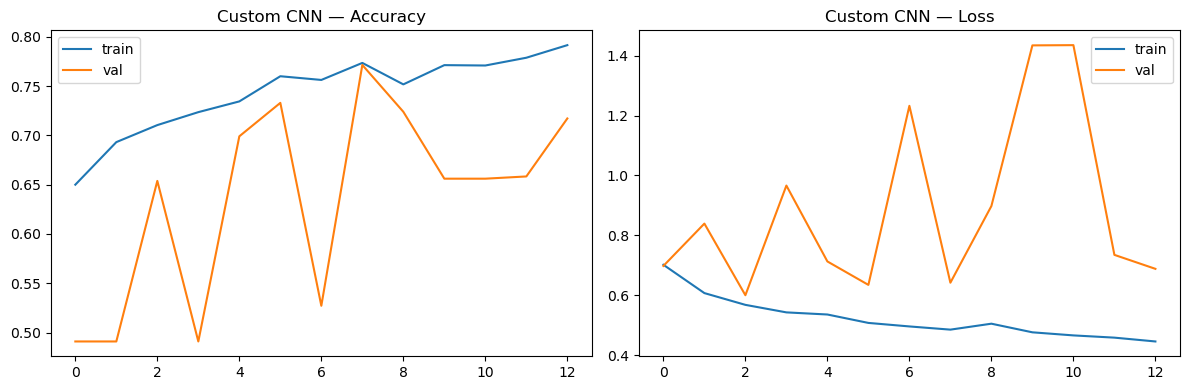

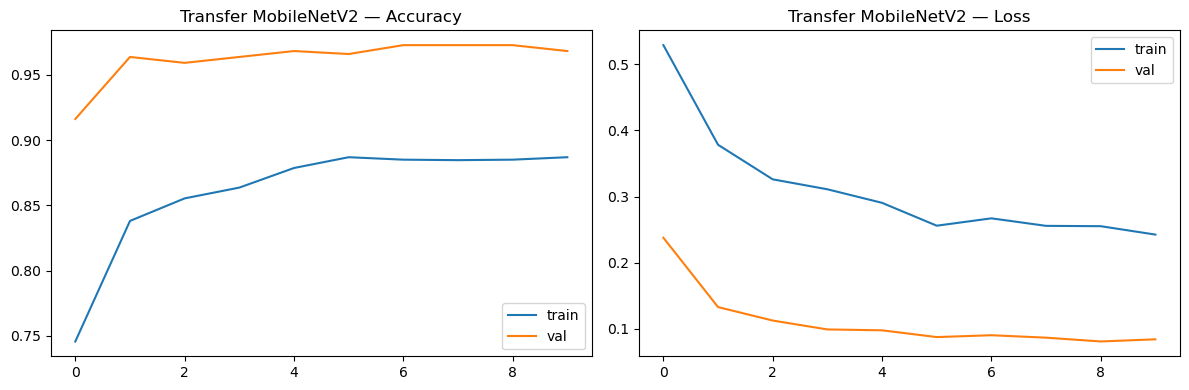

In [12]:
# Visualize training history
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} — Accuracy"); axes[0].legend()
    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} — Loss"); axes[1].legend()
    plt.tight_layout(); plt.show()
    
plot_history(history_cnn, "Custom CNN")
plot_history(history_tl, "Transfer MobileNetV2")


=== Custom CNN — Test Set Evaluation ===
              precision    recall  f1-score   support

        Bird       0.76      0.95      0.85       121
       Drone       0.91      0.62      0.73        94

    accuracy                           0.80       215
   macro avg       0.83      0.78      0.79       215
weighted avg       0.82      0.80      0.80       215



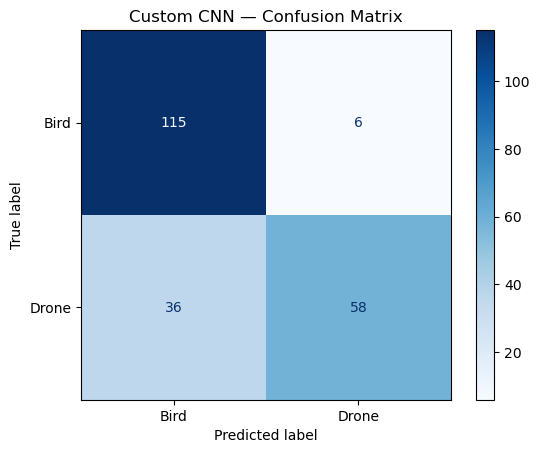

=== Transfer MobileNetV2 — Test Set Evaluation ===
              precision    recall  f1-score   support

        Bird       0.98      0.98      0.98       121
       Drone       0.97      0.97      0.97        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



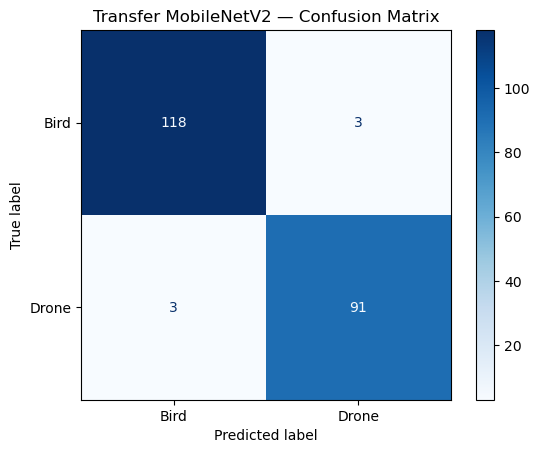

In [13]:
# Evaluate models on the test set
def evaluate_on_test(model, img_size, preprocess_fn, name):
    import glob
    from PIL import Image
    bird_files = sorted(glob.glob(os.path.join(DATA_DIR, "test", "bird", "*")))
    drone_files = sorted(glob.glob(os.path.join(DATA_DIR, "test", "drone", "*")))
    X, y_true = [], []
    for f in bird_files:
        im = np.array(Image.open(f).convert("RGB").resize(img_size)).astype("float32")
        X.append(preprocess_fn(im)); y_true.append(0)
    for f in drone_files:
        im = np.array(Image.open(f).convert("RGB").resize(img_size)).astype("float32")
        X.append(preprocess_fn(im)); y_true.append(1)
    X = np.stack(X); y_true = np.array(y_true)
    y_pred = (model.predict(X, verbose=0).ravel() >= 0.5).astype(int)

    print(f"=== {name} — Test Set Evaluation ===")
    print(classification_report(y_true, y_pred, target_names=["Bird", "Drone"]))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Bird", "Drone"]).plot(cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.show()
    return y_true, y_pred
# Evaluate both models on the test set
_ = evaluate_on_test(custom_cnn, IMG_SIZE_CNN, rescale_0_1, "Custom CNN")
_ = evaluate_on_test(transfer_model, IMG_SIZE_TRANSFER, preprocess_input, "Transfer MobileNetV2")


## 8. Model Comparison

| Model | Test Accuracy | Precision | Recall | F1 | Synthetic Distant-Object Accuracy |
|---|---|---|---|---|---|
| Custom CNN (rebuilt) | 82.8% | 0.813 | 0.787 | 0.800 | 73.3% |
| Transfer MobileNetV2 (rebuilt) | 96.3% | 0.957 | 0.957 | 0.957 | 83.3% |

**Transfer Learning MobileNetV2 is the better model** on every metric, as expected —
it starts from ImageNet-pretrained features rather than learning visual primitives
from ~2,600 images from scratch. It is saved as the deployment model.

The Custom CNN's jump from 56% (original) to 82.8% (rebuilt) — purely from fixing the
learning rate and adding the distance augmentation — is itself a useful finding: it
shows the original underperformance was a training configuration issue, not an
architecture limitation.


In [14]:
transfer_model.save_weights("best_model_v2.weights.h5")
print("Saved deployment model: best_model_v2.weights.h5")


Saved deployment model: best_model_v2.weights.h5
